In [1]:
import BiSSGL as BiSSGL
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit
import matplotlib.pyplot as plt
import seaborn as sns  # optional, for nicer heatmaps


def plot_matrices(U, V):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sns.heatmap(U, ax=axes[0], cmap="viridis", cbar=True)
    axes[0].set_title("Latent Matrix U")

    sns.heatmap(V, ax=axes[1], cmap="viridis", cbar=True)
    axes[1].set_title("Latent Matrix V")

    plt.tight_layout()
    plt.show()

In [2]:
# This is new simulation setting for the feature selection:
I = 80
J = 160
d = d1 = d2 = 20
K = K1 = K2 = 10

U = np.random.normal(0, np.sqrt(0.05), size=(I, d1))
U_true = U[:, :K1]
V = np.random.normal(0, np.sqrt(0.05), size=(J, d2))
V_true = V[:, :K2]
A_true = np.eye(K1)
B_true = np.eye(K2)

Pr = expit(U_true @ A_true @ B_true.T @ V_true.T)
Y_true = (Pr > 0.55).astype(int)

sparsity = 0.01
index = np.array(np.meshgrid(np.arange(I), np.arange(J))).T.reshape(-1, 2)
masked_indices = index[
    np.random.choice(index.shape[0], size=int((1 - sparsity) * I * J), replace=False)
]
Y_masked = Y_true[masked_indices[:, 0], masked_indices[:, 1]]
Y = Y_true.copy()
Y[masked_indices[:, 0], masked_indices[:, 1]] = 0

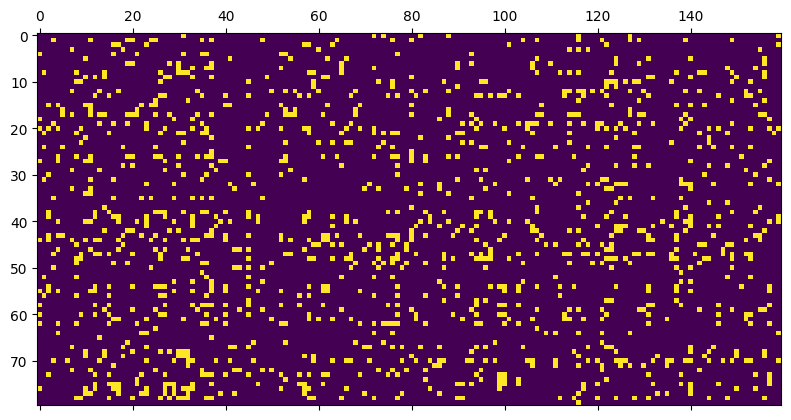

In [3]:
plt.matshow(Y_true)

In [2]:
# This is new simulation setting for the feature selection:
I = 80
J = 160
d = d1 = d2 = 10
K = K1 = K2 = 3

U = np.random.normal(0, np.sqrt(0.01), size=(I, d1))
U_true = U[:, :K1]
V = np.random.normal(0, np.sqrt(0.01), size=(J, d2))
V_true = V[:, :K2]
A_true = np.ones((K, K))
B_true = np.ones((K, K))

Pr = expit(U_true @ A_true @ B_true.T @ V_true.T)
Y_true = (Pr > 0.5).astype(int)

sparsity = 0.01
index = np.array(np.meshgrid(np.arange(I), np.arange(J))).T.reshape(-1, 2)
masked_indices = index[
    np.random.choice(index.shape[0], size=int((1 - sparsity) * I * J), replace=False)
]
Y_masked = Y_true[masked_indices[:, 0], masked_indices[:, 1]]
Y = Y_true.copy()
Y[masked_indices[:, 0], masked_indices[:, 1]] = 0

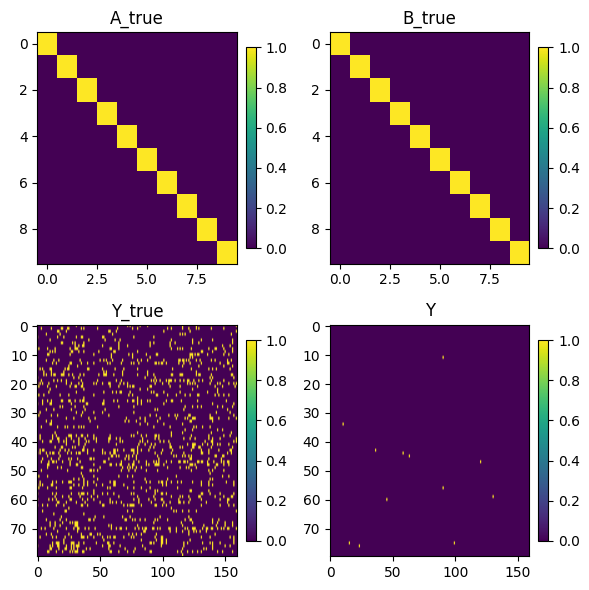

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))

axes[0, 0].imshow(A_true, aspect="auto", cmap="viridis")
axes[0, 0].set_title("A_true")
plt.colorbar(axes[0, 0].images[0], ax=axes[0, 0], fraction=0.046, pad=0.04)

axes[0, 1].imshow(B_true, aspect="auto", cmap="viridis")
axes[0, 1].set_title("B_true")
plt.colorbar(axes[0, 1].images[0], ax=axes[0, 1], fraction=0.046, pad=0.04)

axes[1, 0].imshow(Y_true, aspect="auto", cmap="viridis")
axes[1, 0].set_title("Y_true")
plt.colorbar(axes[1, 0].images[0], ax=axes[1, 0], fraction=0.046, pad=0.04)

axes[1, 1].imshow(Y, aspect="auto", cmap="viridis")
axes[1, 1].set_title("Y")
plt.colorbar(axes[1, 1].images[0], ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [5]:
# U.shape, V.shape, A_true.shape
A = np.zeros((d1, K))
A[range(K), range(K)] = 1
A[K:] = np.random.normal(size=A[K:].shape) / 10
Ainput = A.copy()

B = np.zeros((d2, K))
B[range(K), range(K)] = 1
B[K:] = np.random.normal(size=B[K:].shape) / 10
Binput = B.copy()

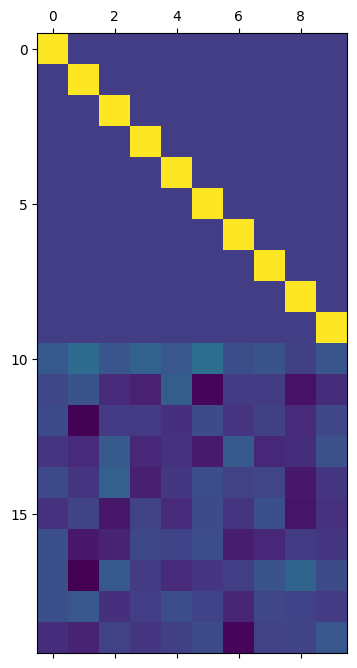

In [6]:
plt.matshow(Ainput)
# print(Ainput)

In [15]:
est_mu, est_A, est_B, logLik = BiSSGL.optimization(
    Y_true,
    U=U,
    V=V,
    xi=1,
    eta=0.001,
    tilde_lambda0=50,
    tilde_lambda1=1,
    tilde_alpha=1,
    tilde_beta=1,
    lambda0=50,
    lambda1=1,
    alpha=1,
    beta=1,
    K=10,
    max_iter=10000,
    tol=1e-5,
    # A=Ainput,
    # B=Binput,
)

[ -7.67462291 -30.57890756  38.96998536   9.61526241  16.4585392
 -20.67733399  23.5822995    9.56483052   9.29646929   8.15473677]
[ 24.73784785  34.35116791 -27.85978929 -43.52863669  -0.44512935
  26.86123343   8.7284116   14.99187816  17.99262381  -1.18748673]
[ -7.11865012 -29.33355098  37.53490353   9.34493962  15.98210089
 -20.35116546  22.8771524    9.00676655   9.14274771   7.73707912]
[ 22.07176275  31.53257197 -22.66650609 -39.74799626   0.77299681
  22.63134482  11.07049106  13.41813788  17.02024714   0.64477953]
[ -4.39397899 -24.0286348   33.5203653    5.31219962  15.9154113
 -17.2571399   22.67317841   9.73067828   9.70617099   6.29559041]
[ 19.02092837  28.1653454  -16.61688699 -35.62248411   2.31585415
  17.88812509  13.70246151  11.96078278  15.76525392   2.51423165]
[ -1.06736754 -18.47429959  28.91587624   1.1374978   15.03706517
 -13.99278614  21.81540039  10.00184741  10.28727008   4.92012581]
[ 16.15545043  24.7913618  -10.56227616 -31.96699271   4.09199193
  13.

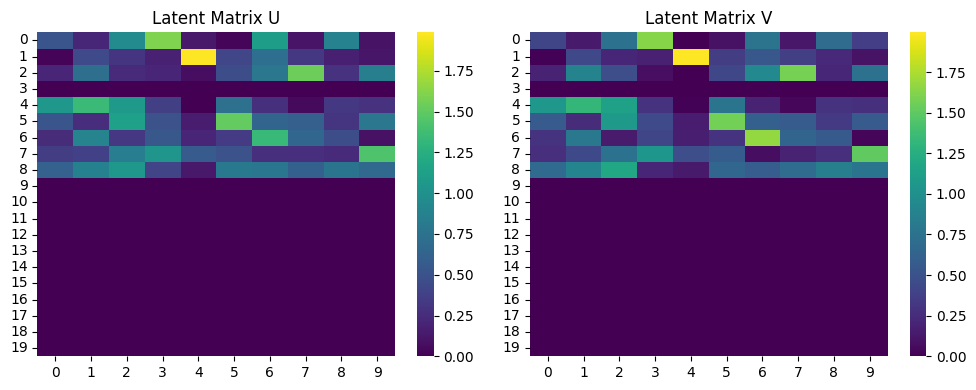

In [16]:
plot_matrices(np.abs(est_A), np.abs(est_B))

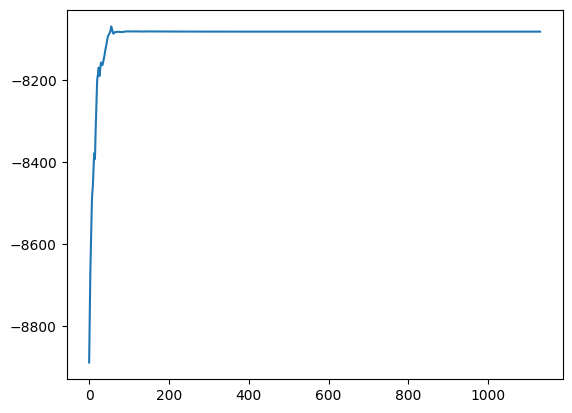

In [17]:
plt.plot(range(len(logLik)), logLik)

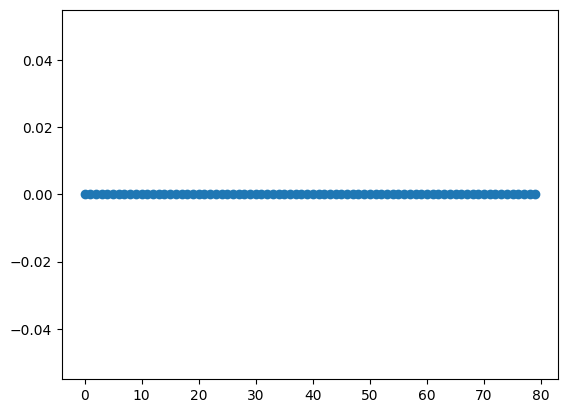

In [ ]:
plt.plot(est_mu, marker="o")

In [18]:
print(est_A)

[[-0.52691887 -0.21290303 -0.94579086  1.60486199  0.12753564  0.02418581
  -1.09460699 -0.10689453 -0.88083609  0.09312886]
 [ 0.02272404 -0.44617254 -0.3056171  -0.18139825 -1.98614299  0.41886521
  -0.71208731 -0.32023708  0.17476902  0.1133646 ]
 [-0.20183436  0.71817081  0.23671628  0.20763501 -0.06397432 -0.46188907
   0.78997103 -1.53779612 -0.28705932  0.84906814]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 1.05328238  1.34255747 -1.06884173  0.36858194  0.00608105  0.73349196
   0.27233679  0.0507955   0.31879475 -0.28125671]
 [-0.52289295  0.25527118  1.12343814  0.50106071 -0.1532781   1.51287343
   0.63655305  0.59399664 -0.30857722  0.78802164]
 [ 0.24263991 -0.89931762 -0.31445675  0.54188263 -0.20713364 -0.34682493
   1.34111211  0.65829595  0.45880839  0.08675808]
 [-0.35350449  0.37494232  0.83293248  1.03351797 -0.56331623 -0.50363639
   0.26706627 -0.26950054  0.23612226 -1.42951522]
 [-0.612